<a href="https://colab.research.google.com/github/Jgour5454/Brain-Tumor-Detection-DL/blob/main/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Processing val: 100%|██████████| 613/613 [00:04<00:00, 130.27it/s]

Found 2451 images belonging to 3 classes.


Found 613 images belonging to 3 classes.
🏗️ Building VGG16 Model...
🚀 Training VGG16 on T4 GPU...
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 51s 625ms/step - accuracy: 0.4619 - loss: 1.0577 - val_accuracy: 0.6052 - val_loss: 0.9428
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 38s 490ms/step - accuracy: 0.5581 - loss: 0.9362 - val_accuracy: 0.6754 - val_loss: 0.8647
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 36s 473ms/step - accuracy: 0.6340 - loss: 0.8456 - val_accuracy: 0.6705 - val_loss: 0.7945
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 38s 490ms/step - accuracy: 0.6679 - loss: 0.7833 - val_accuracy: 0.7308 - val_loss: 0.7311
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 36s 471ms/step - accuracy: 0.7046 - loss: 0.7178 - val_accuracy: 0.7651 - val_loss: 0.7003
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 37s 481ms/step - accuracy: 0.7311 - loss: 0.6729 - val_accuracy: 0.7651 - val_loss: 0.6556
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 37s 479ms/step - accuracy: 0.7674 - loss: 0.6240 - val_accuracy: 0.7749 - val_loss: 0.6202


      VGG16 FINAL RESULTS
Total Accuracy:  87.44%
Kappa Score:     0.8032 (Agreement)
MCC Score:       0.8039 (Correlation)

Detailed Report:
               precision    recall  f1-score   support

  meningioma       0.90      0.87      0.89       292
      glioma       0.79      0.75      0.77       150
   pituitary       0.89      0.98      0.94       171

    accuracy                           0.87       613
   macro avg       0.86      0.87      0.87       613
weighted avg       0.87      0.87      0.87       613



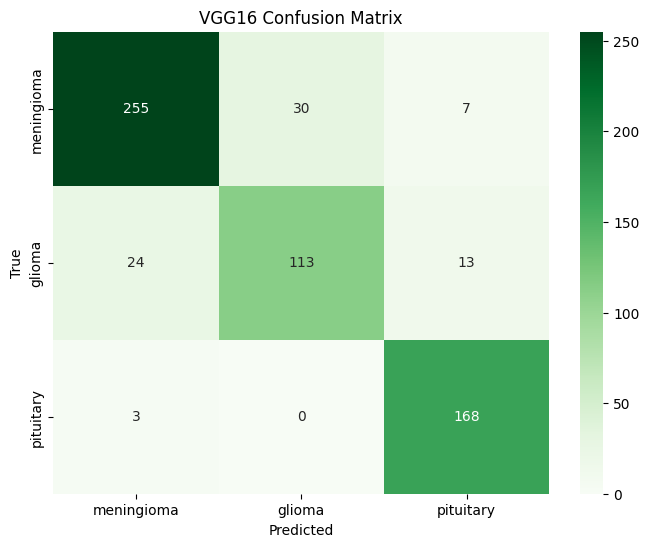

In [ ]:
# ==============================================================================
# 1. SETUP & DISK-BASED DATA PREPARATION
# ==============================================================================
import os, zipfile, scipy.io, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, matthews_corrcoef
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Paths
ZIP_PATH = '/content/drive/MyDrive/ML/1512427.zip'
MAT_DIR = '/content/all_mats'
BASE_DATA_DIR = '/content/brain_tumor_vgg16'
TRAIN_DIR = os.path.join(BASE_DATA_DIR, 'train')
VAL_DIR = os.path.join(BASE_DATA_DIR, 'val')

# Step 1: Extract Dataset if not already extracted
if not os.path.exists(MAT_DIR):
    print("📦 Extracting Dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/raw')
    os.makedirs(MAT_DIR, exist_ok=True)
    for nz in [f for f in os.listdir('/content/raw') if f.endswith('.zip')]:
        with zipfile.ZipFile(os.path.join('/content/raw', nz), 'r') as z:
            z.extractall(MAT_DIR)

# Step 2: Organize into folders (Meningioma, Glioma, Pituitary)
categories = ['meningioma', 'glioma', 'pituitary']
for cat in categories:
    os.makedirs(os.path.join(TRAIN_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cat), exist_ok=True)

mat_files = [f for f in os.listdir(MAT_DIR) if f.endswith('.mat')]
train_files, val_files = train_test_split(mat_files, test_size=0.2, random_state=42)

def convert_to_disk(file_list, target_dir):
    for fname in tqdm(file_list, desc=f"Processing {target_dir.split('/')[-1]}"):
        try:
            try:
                m = scipy.io.loadmat(os.path.join(MAT_DIR, fname))['cjdata'][0][0]
                lbl, img = int(m[0][0][0])-1, m[2].astype(np.float32)
            except:
                import h5py
                with h5py.File(os.path.join(MAT_DIR, fname), 'r') as f:
                    lbl, img = int(f['cjdata']['label'][0][0])-1, np.array(f['cjdata']['image']).T

            # Normalize to 0-255 and resize to VGG16 standard (224x224)
            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
            img = cv2.resize(img, (224, 224))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # VGG requires 3 channels
            cv2.imwrite(os.path.join(target_dir, categories[lbl], fname.replace('.mat', '.jpg')), img_rgb)
        except: continue

convert_to_disk(train_files, TRAIN_DIR)
convert_to_disk(val_files, VAL_DIR)

# ==============================================================================
# 2. DATA GENERATORS (Low RAM & GPU Optimization)
# ==============================================================================
# Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)

# Rescaling only for Validation
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical')

# shuffle=False is MANDATORY for correct Kappa/MCC calculation
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

# ==============================================================================
# 3. VGG16 MODEL BUILDING (Fine-Tuning)
# ==============================================================================
print("🏗️ Building VGG16 Model...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base layers (Pre-trained knowledge)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================================================================
# 4. TRAINING & EVALUATION
# ==============================================================================
print("🚀 Training VGG16 on T4 GPU...")
history = model.fit(train_gen, validation_data=val_gen, epochs=50)

print("\n📊 Evaluating Final Metrics...")
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

# Advanced Metrics Calculation
accuracy = np.mean(y_pred == y_true)
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print(f"\n" + "="*35)
print(f"      VGG16 FINAL RESULTS")
print(f"="*35)
print(f"Total Accuracy:  {accuracy*100:.2f}%")
print(f"Kappa Score:     {kappa:.4f} (Agreement)")
print(f"MCC Score:       {mcc:.4f} (Correlation)")
print(f"\nDetailed Report:\n", classification_report(y_true, y_pred, target_names=categories))

# Save the Model and Confusion Matrix
model.save('/content/drive/MyDrive/ML/vgg16_brain_final.h5')

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=categories, yticklabels=categories)
plt.title('VGG16 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()